# Dot Plot of Scube1 Expression in Dorsal & Ventral Striatum

This notebook creates a dot plot of **Scube1** gene expression across cell subclasses
in the dorsal striatum (STRd) and ventral striatum (STRv) using 10x snRNA-seq data
from the Allen Brain Cell (ABC) Atlas.

Additional marker genes are included for cell-type identification:
- **Drd1** / **Drd2** — D1 vs D2 medium spiny neurons
- **Chat** — cholinergic interneurons
- **Pvalb** / **Sst** — GABAergic interneuron subtypes
- **Th** — dopaminergic/catecholaminergic marker
- **Foxp2** — expressed in a subset of MSNs
- **Aqp4** — astrocyte marker
- **Mog** — oligodendrocyte marker

Cortical cell types that may be incidentally captured in striatum dissections are excluded.

In [1]:
import pandas as pd
import numpy as np
import re
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache
from abc_atlas_access.abc_atlas_cache.anndata_utils import get_gene_data

## 1. Initialize the ABC Atlas Cache

In [2]:
download_base = Path('../../data/abc_atlas')
abc_cache = AbcProjectCache.from_s3_cache(download_base)

print(f"Current manifest: {abc_cache.current_manifest}")

Current manifest: releases/20260228/manifest.json


## 2. Load Cell Metadata and Taxonomy

In [3]:
# Load cell metadata
cell = abc_cache.get_metadata_dataframe(
    directory='WMB-10X',
    file_name='cell_metadata',
    dtype={'cell_label': str}
)
cell.set_index('cell_label', inplace=True)
print(f"Total cells in WMB-10X: {len(cell):,}")

Total cells in WMB-10X: 4,042,976


In [4]:
# Load gene metadata
gene = abc_cache.get_metadata_dataframe(
    directory='WMB-10X',
    file_name='gene'
)
gene.set_index('gene_identifier', inplace=True)
print(f"Total genes: {len(gene):,}")

Total genes: 32,285


In [5]:
# Load cluster taxonomy pivot table
cluster_details = abc_cache.get_metadata_dataframe(
    directory='WMB-taxonomy',
    file_name='cluster_to_cluster_annotation_membership_pivoted',
    keep_default_na=False
)
cluster_details.set_index('cluster_alias', inplace=True)

# Join taxonomy annotations onto cell metadata
cell_extended = cell.join(cluster_details, on='cluster_alias')
print(f"Taxonomy levels: {list(cluster_details.columns)}")

Taxonomy levels: ['neurotransmitter', 'class', 'subclass', 'supertype', 'cluster']


## 3. Filter to Striatum Cells and Exclude Cortical Types

In [6]:
# Filter to dorsal and ventral striatum dissection regions
str_rois = ['STRd', 'STRv']
str_cells = cell_extended[cell_extended['region_of_interest_acronym'].isin(str_rois)].copy()
print(f"Cells in striatum regions: {len(str_cells):,}")
for roi, count in str_cells.groupby('region_of_interest_acronym').size().items():
    print(f"  {roi}: {count:,}")

# Show all subclasses present
print(f"\nAll subclasses found in striatum dissections:")
subclass_counts = str_cells.groupby('subclass', observed=True).size().sort_values(ascending=False)
for sc_name, count in subclass_counts.items():
    print(f"  {sc_name}: {count:,} cells")

Cells in striatum regions: 109,199
  STRd: 55,626
  STRv: 53,573

All subclasses found in striatum dissections:
  062 STR D2 Gaba: 29,287 cells
  061 STR D1 Gaba: 29,010 cells
  319 Astro-TE NN: 12,179 cells
  060 OT D3 Folh1 Gaba: 7,665 cells
  327 Oligo NN: 6,221 cells
  334 Microglia NN: 3,963 cells
  063 STR D1 Sema5a Gaba: 3,487 cells
  333 Endo NN: 3,377 cells
  326 OPC NN: 3,031 cells
  045 OB-STR-CTX Inh IMN: 2,725 cells
  064 STR-PAL Chst9 Gaba: 1,786 cells
  331 Peri NN: 919 cells
  054 STR Prox1 Lhx6 Gaba: 779 cells
  056 Sst Chodl Gaba: 565 cells
  055 STR Lhx8 Gaba: 504 cells
  332 SMC NN: 488 cells
  081 ACB-BST-FS D1 Gaba: 307 cells
  330 VLMC NN: 287 cells
  318 Astro-NT NN: 279 cells
  335 BAM NN: 267 cells
  030 L6 CT CTX Glut: 252 cells
  041 OB-in Frmd7 Gaba: 190 cells
  010 IT AON-TT-DP Glut: 164 cells
  004 L6 IT CTX Glut: 134 cells
  058 PAL-STR Gaba-Chol: 107 cells
  119 SI-MA-LPO-LHA Skor1 Glut: 105 cells
  066 NDB-SI-ant Prdm12 Gaba: 96 cells
  014 LA-BLA-BMA-

In [7]:
# Exclude cortical cell types that are incidentally captured in striatum dissections.
# These are identifiable by 'CTX' in their subclass name or by belonging to cortical classes.
cortex_patterns = ['CTX', 'L2/3', 'L4/5', 'L5 ', 'L6 ', 'L6b', 'RSP']

def is_cortical(subclass_name):
    """Return True if subclass name indicates a cortical cell type."""
    return any(pat in subclass_name for pat in cortex_patterns)

cortical_subclasses = [s for s in str_cells['subclass'].unique() if is_cortical(s)]
if cortical_subclasses:
    print(f"Excluding {len(cortical_subclasses)} cortical subclasses:")
    for s in sorted(cortical_subclasses):
        n = (str_cells['subclass'] == s).sum()
        print(f"  {s}: {n:,} cells")
    str_cells = str_cells[~str_cells['subclass'].isin(cortical_subclasses)].copy()
else:
    print("No cortical subclasses found — no exclusions needed.")

print(f"\nCells after excluding cortex types: {len(str_cells):,}")

Excluding 7 cortical subclasses:
  004 L6 IT CTX Glut: 134 cells
  009 L2/3 IT PIR-ENTl Glut: 14 cells
  027 L6b EPd Glut: 12 cells
  029 L6b CTX Glut: 17 cells
  030 L6 CT CTX Glut: 252 cells
  032 L5 NP CTX Glut: 1 cells
  045 OB-STR-CTX Inh IMN: 2,725 cells

Cells after excluding cortex types: 106,044


In [8]:
# Show final subclass breakdown
print("Striatum subclasses (after cortex exclusion):")
subclass_counts = str_cells.groupby('subclass', observed=True).size().sort_values(ascending=False)
for sc_name, count in subclass_counts.items():
    print(f"  {sc_name}: {count:,} cells")

Striatum subclasses (after cortex exclusion):
  062 STR D2 Gaba: 29,287 cells
  061 STR D1 Gaba: 29,010 cells
  319 Astro-TE NN: 12,179 cells
  060 OT D3 Folh1 Gaba: 7,665 cells
  327 Oligo NN: 6,221 cells
  334 Microglia NN: 3,963 cells
  063 STR D1 Sema5a Gaba: 3,487 cells
  333 Endo NN: 3,377 cells
  326 OPC NN: 3,031 cells
  064 STR-PAL Chst9 Gaba: 1,786 cells
  331 Peri NN: 919 cells
  054 STR Prox1 Lhx6 Gaba: 779 cells
  056 Sst Chodl Gaba: 565 cells
  055 STR Lhx8 Gaba: 504 cells
  332 SMC NN: 488 cells
  081 ACB-BST-FS D1 Gaba: 307 cells
  330 VLMC NN: 287 cells
  318 Astro-NT NN: 279 cells
  335 BAM NN: 267 cells
  041 OB-in Frmd7 Gaba: 190 cells
  010 IT AON-TT-DP Glut: 164 cells
  058 PAL-STR Gaba-Chol: 107 cells
  119 SI-MA-LPO-LHA Skor1 Glut: 105 cells
  066 NDB-SI-ant Prdm12 Gaba: 96 cells
  014 LA-BLA-BMA-PA Glut: 76 cells
  042 OB-out Frmd7 Gaba: 72 cells
  039 OB Meis2 Thsd7b Gaba: 70 cells
  080 CEA-AAA-BST Six3 Sp9 Gaba: 66 cells
  323 Ependymal NN: 62 cells
  049 La

## 4. Define Gene List

In [9]:
# Primary gene of interest
primary_gene = ['Scube1']

# MSN identity markers
msn_markers = ['Drd1', 'Drd2', 'Foxp2']

# Interneuron / other neuron markers
interneuron_markers = ['Chat', 'Pvalb', 'Sst', 'Th']

# Glial markers
glial_markers = ['Aqp4', 'Mog']

all_genes_list = primary_gene + msn_markers + interneuron_markers + glial_markers

# Verify genes are present in the dataset
available_genes = gene[gene['gene_symbol'].isin(all_genes_list)]
found_symbols = set(available_genes['gene_symbol'])
missing = [g for g in all_genes_list if g not in found_symbols]
if missing:
    print(f"WARNING — genes not found in dataset: {missing}")

gene_list = [g for g in all_genes_list if g in found_symbols]
print(f"Genes for dot plot ({len(gene_list)}): {gene_list}")

Genes for dot plot (10): ['Scube1', 'Drd1', 'Drd2', 'Foxp2', 'Chat', 'Pvalb', 'Sst', 'Th', 'Aqp4', 'Mog']


## 5. Load Expression Data

In [10]:
# Extract expression for selected genes from all striatum cells.
# This uses the anndata_utils helper which handles chunked reading
# across multiple h5ad files.
expression_data = get_gene_data(
    abc_atlas_cache=abc_cache,
    all_cells=str_cells,
    all_genes=gene,
    selected_genes=gene_list,
    data_type='log2'
)

# Drop any rows that are all NaN (cells not found in expression files)
expression_data = expression_data.dropna(how='all')
print(f"Expression data: {expression_data.shape[0]:,} cells x {expression_data.shape[1]} genes")

loading file: WMB-10Xv3-STR


 - time taken:  95.46786592499998
total time taken: 95.46922713499998
	total cells: 106044 processed cells: 106044
Expression data: 106,044 cells x 10 genes


## 6. Build AnnData Object

In [11]:
# Align cells: keep only cells present in both metadata and expression data
common_cells = str_cells.index.intersection(expression_data.index)
expression_data = expression_data.loc[common_cells, gene_list]
str_cells_aligned = str_cells.loc[common_cells]

# Add a region label for faceting
region_map = {'STRd': 'Dorsal striatum', 'STRv': 'Ventral striatum'}
str_cells_aligned['region_label'] = str_cells_aligned['region_of_interest_acronym'].map(region_map)

# Create AnnData
adata = anndata.AnnData(
    X=expression_data.values.astype(np.float32),
    obs=str_cells_aligned[['subclass', 'supertype', 'class', 'region_of_interest_acronym', 'region_label']].copy(),
    var=pd.DataFrame(index=gene_list)
)

# Create shorter display labels (strip leading number prefix)
adata.obs['subclass_short'] = adata.obs['subclass'].apply(
    lambda x: re.sub(r'^\d+\s+', '', x)
)

adata.obs['subclass_short'] = pd.Categorical(adata.obs['subclass_short'])
adata.obs['subclass'] = pd.Categorical(adata.obs['subclass'])

n_subclasses = adata.obs['subclass'].cat.categories.size
print(adata)
print(f"\n{n_subclasses} subclasses, {len(common_cells):,} cells")

AnnData object with n_obs × n_vars = 106044 × 10
    obs: 'subclass', 'supertype', 'class', 'region_of_interest_acronym', 'region_label', 'subclass_short'

70 subclasses, 106,044 cells


## 6b. Add Chat+ Manually Selected Cells as a Separate Group

Identify all cells with Chat expression > 0 (regardless of subclass) and add them
as a duplicate group called **"Chat+ (manual select)"**, placed immediately after
the PAL-STR Gaba-Chol row in every dot plot.

In [12]:
# Identify Chat+ cells: any cell with Chat expression > 0
chat_col_idx = list(adata.var_names).index('Chat')
chat_expr = adata.X[:, chat_col_idx]
chat_mask = chat_expr > 0
n_chat_pos = chat_mask.sum()
print(f"Chat+ cells (expression > 0): {n_chat_pos:,} out of {adata.n_obs:,}")

# Create a duplicate AnnData for Chat+ cells with a new group label
adata_chat = adata[chat_mask].copy()
adata_chat.obs['subclass_short'] = 'Chat+ (manual select)'
adata_chat.obs['subclass'] = 'Chat+ (manual select)'

# Concatenate: original adata + Chat+ duplicate rows
adata_with_chat = anndata.concat([adata, adata_chat])

# Build ordered category list: insert "Chat+ (manual select)" right after PAL-STR Gaba-Chol
original_cats = list(adata.obs['subclass_short'].cat.categories)
# Sort by the original numeric prefix (already sorted alphabetically which ~matches)
insert_after = 'PAL-STR Gaba-Chol'
if insert_after in original_cats:
    idx = original_cats.index(insert_after) + 1
    ordered_cats = original_cats[:idx] + ['Chat+ (manual select)'] + original_cats[idx:]
else:
    ordered_cats = original_cats + ['Chat+ (manual select)']

adata_with_chat.obs['subclass_short'] = pd.Categorical(
    adata_with_chat.obs['subclass_short'],
    categories=ordered_cats,
    ordered=True
)

# Print n for each group
print(f"\nCell counts per group (all striatum):")
group_counts = adata_with_chat.obs.groupby('subclass_short', observed=True).size()
for name in ordered_cats:
    if name in group_counts.index:
        print(f"  {name}: n={group_counts[name]:,}")

n_groups = len([c for c in ordered_cats if c in group_counts.index])
print(f"\nTotal groups for dotplot: {n_groups}")

Chat+ cells (expression > 0): 2,489 out of 106,044

Cell counts per group (all striatum):
  ABC NN: n=10
  ACB-BST-FS D1 Gaba: n=307
  AVPV-MEPO-SFO Tbr1 Glut: n=3
  Astro-NT NN: n=279
  Astro-OLF NN: n=2
  Astro-TE NN: n=12,179
  Astroependymal NN: n=1
  BAM NN: n=267
  BST-MPN Six3 Nrgn Gaba: n=8
  BST-SI-AAA Six3 Slc22a3 Gaba: n=6
  CEA-AAA-BST Six3 Sp9 Gaba: n=66
  CEA-BST Ebf1 Pdyn Gaba: n=14
  CEA-BST Rai14 Pdyn Crh Gaba: n=5
  CEA-BST Six3 Cyp26b1 Gaba: n=23
  DC NN: n=13
  DG-PIR Ex IMN: n=19
  Endo NN: n=3,377
  Ependymal NN: n=62
  GPe-SI Sox6 Cyp26b1 Gaba: n=22
  HPF CR Glut: n=51
  IA Mgp Gaba: n=31
  IT AON-TT-DP Glut: n=164
  IT EP-CLA Glut: n=44
  LA-BLA-BMA-PA Glut: n=76
  LSX Nkx2-1 Gaba: n=1
  LSX Prdm12 Slit2 Gaba: n=39
  LSX Prdm12 Zeb2 Gaba: n=5
  LSX Sall3 Pax6 Gaba: n=4
  Lamp5 Gaba: n=60
  Lamp5 Lhx6 Gaba: n=4
  Lymphoid NN: n=9
  MEA-BST Lhx6 Nr2e1 Gaba: n=2
  MEA-BST Sox6 Gaba: n=1
  MPO-ADP Lhx8 Gaba: n=8
  MS-SF Bsx Glut: n=2
  Microglia NN: n=3,963
  Monocy

/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [13]:
from scipy.stats import trim_mean
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# White-to-magenta colormap
_MAGENTA_CMAP = mcolors.LinearSegmentedColormap.from_list(
    'wt_magenta', ['#FFFFFF', '#FFCCEE', '#FF66BB', '#DD0088', '#990066']
)

def custom_dotplot(adata, gene_groups, groupby, title=None, figsize=None,
                   outpath=None, vmax=11):
    """Dotplot with trimmed mean (25%-75%) color and fraction-expressing size.

    Color: trimmed mean Log2(CPM+1), white-to-magenta (0 to vmax).
    Size:  fraction of cells with >0 expression.
    """
    # Flatten gene groups, track spans for header labels
    flat_genes = []
    group_spans = []
    for gname, genes in gene_groups.items():
        start = len(flat_genes)
        flat_genes.extend(genes)
        group_spans.append((start, len(flat_genes) - 1, gname))

    categories = list(adata.obs[groupby].cat.categories)
    n_cats = len(categories)
    n_genes = len(flat_genes)

    # Compute trimmed mean and fraction expressing per group
    expr = pd.DataFrame(adata.X, index=adata.obs.index, columns=adata.var_names)
    grp = adata.obs[groupby].values

    tm = np.zeros((n_cats, n_genes))
    frac = np.zeros((n_cats, n_genes))

    for i, cat in enumerate(categories):
        mask = grp == cat
        if mask.sum() == 0:
            continue
        cat_vals = expr.loc[mask, flat_genes].values.astype(float)
        for j in range(n_genes):
            vals = cat_vals[:, j]
            frac[i, j] = (vals > 0).mean()
            tm[i, j] = trim_mean(vals, proportiontocut=0.25)

    # Plot setup
    cmap = _MAGENTA_CMAP
    norm = mcolors.Normalize(vmin=0, vmax=vmax)
    max_s, min_s = 220, 12

    if figsize is None:
        figsize = (max(10, n_genes * 1.3 + 5), max(6, n_cats * 0.45))

    fig, ax = plt.subplots(figsize=figsize)

    # Draw dots
    for i in range(n_cats):
        yi = n_cats - 1 - i
        for j in range(n_genes):
            f = frac[i, j]
            if f < 0.005:
                continue
            t = min(tm[i, j], vmax)
            size = min_s + (max_s - min_s) * min(f, 1.0)
            ax.scatter(j, yi, s=size, c=[cmap(norm(t))],
                       edgecolors='black', linewidths=0.5, zorder=3)

    # Axes
    ax.set_yticks(range(n_cats))
    ax.set_yticklabels(list(reversed(categories)), fontsize=8)
    ax.set_xticks(range(n_genes))
    ax.set_xticklabels(flat_genes, rotation=90, ha='center', fontsize=9)
    ax.set_xlim(-0.5, n_genes - 0.5)
    ax.set_ylim(-0.5, n_cats - 0.5)

    # Gene-group header labels
    for start, end, gname in group_spans:
        mid = (start + end) / 2
        ax.annotate(gname, xy=(mid, 1.01), xycoords=('data', 'axes fraction'),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Light grid
    for j in range(n_genes + 1):
        ax.axvline(j - 0.5, color='gray', linewidth=0.3, alpha=0.3, zorder=1)
    for i in range(n_cats + 1):
        ax.axhline(i - 0.5, color='gray', linewidth=0.3, alpha=0.3, zorder=1)

    if title:
        ax.set_title(title, fontsize=13, pad=30)

    # --- Size legend: Fraction of cell with >0 read ---
    leg_fracs = [0.2, 0.4, 0.6, 0.8, 1.0]
    handles = [
        Line2D([0], [0], marker='o', color='w', linestyle='None',
               markersize=np.sqrt(min_s + (max_s - min_s) * f) / 1.7,
               markerfacecolor='black', markeredgecolor='black',
               markeredgewidth=0.5, label=f'{f}')
        for f in leg_fracs
    ]
    leg = ax.legend(handles=handles, title='Fraction of cell\nwith >0 read',
                    loc='upper left', bbox_to_anchor=(1.02, 1.0),
                    frameon=True, fontsize=8, title_fontsize=9,
                    handletextpad=0.5, labelspacing=1.2)
    ax.add_artist(leg)

    # --- Colorbar: Trimmed mean (25%-75%) Log2(CPM+1) ---
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar_ax = inset_axes(ax, width='3%', height='30%', loc='lower left',
                         bbox_to_anchor=(1.02, 0.0, 1, 1),
                         bbox_transform=ax.transAxes, borderpad=0)
    cbar = fig.colorbar(sm, cax=cbar_ax)
    ticks = list(range(0, vmax + 1))
    tick_labels = [str(t) for t in ticks]
    tick_labels[-1] = f'>{vmax}'
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(tick_labels)
    cbar.set_label('Trimmed mean (25%-75%)\nLog2(CPM+1)', fontsize=9)

    plt.subplots_adjust(right=0.82)
    if outpath:
        fig.savefig(outpath, dpi=150, bbox_inches='tight')
        print(f"Saved: {outpath}")
    plt.show()

print("custom_dotplot helper defined")

custom_dotplot helper defined


## 7. Dot Plot: All Striatum Cell Subclasses

Saved: scube1/dotplot_striatum_Scube1_by_subclass.png


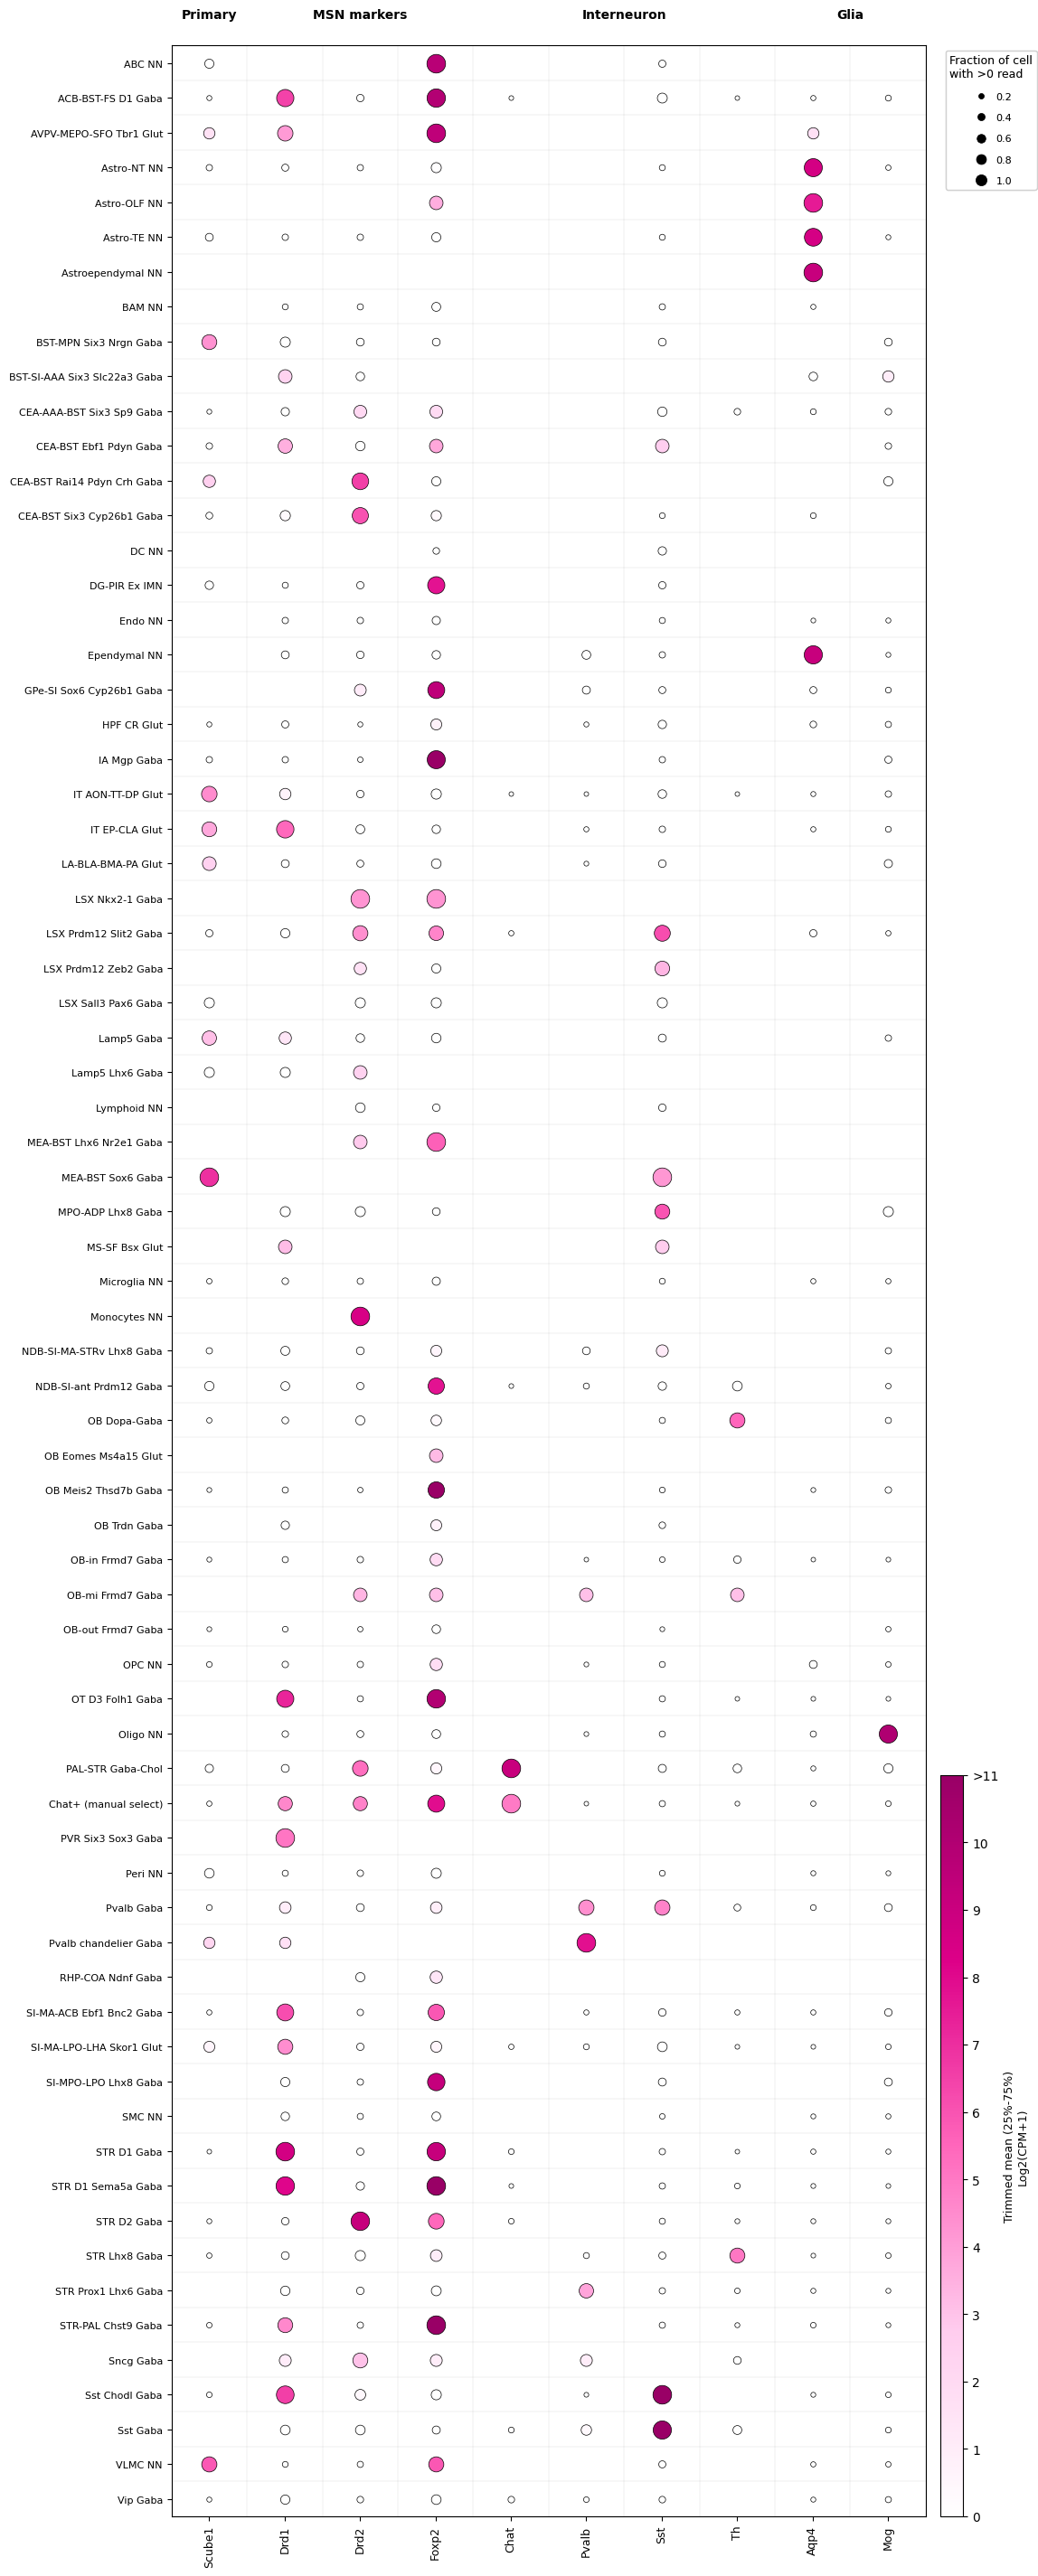

In [14]:
# Define gene groups for the dot plot
gene_groups = {
    'Primary': [g for g in primary_gene if g in gene_list],
    'MSN markers': [g for g in msn_markers if g in gene_list],
    'Interneuron': [g for g in interneuron_markers if g in gene_list],
    'Glia': [g for g in glial_markers if g in gene_list],
}

outdir = Path('scube1')
outdir.mkdir(exist_ok=True)

custom_dotplot(
    adata_with_chat,
    gene_groups=gene_groups,
    groupby='subclass_short',
    figsize=(12, max(6, n_groups * 0.5)),
    outpath=outdir / 'dotplot_striatum_Scube1_by_subclass.png',
)

## 8. Split by Region: Dorsal vs Ventral Striatum

/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")



Dorsal striatum: 55,744 cells, 29 groups
  Astro-NT NN: n=111
  Astro-TE NN: n=6,190
  BAM NN: n=110
  CEA-BST Six3 Cyp26b1 Gaba: n=18
  DG-PIR Ex IMN: n=14
  Endo NN: n=1,811
  Ependymal NN: n=59
  IA Mgp Gaba: n=11
  IT EP-CLA Glut: n=37
  LA-BLA-BMA-PA Glut: n=76
  Lamp5 Gaba: n=15
  Microglia NN: n=2,277
  OB Meis2 Thsd7b Gaba: n=18
  OB-in Frmd7 Gaba: n=77
  OB-out Frmd7 Gaba: n=30
  OPC NN: n=1,331
  Oligo NN: n=3,633
  PAL-STR Gaba-Chol: n=30
  Chat+ (manual select): n=2,117
  Peri NN: n=556
  SMC NN: n=284
  STR D1 Gaba: n=16,660
  STR D1 Sema5a Gaba: n=780
  STR D2 Gaba: n=18,139
  STR Lhx8 Gaba: n=178
  STR Prox1 Lhx6 Gaba: n=367
  STR-PAL Chst9 Gaba: n=437
  Sst Chodl Gaba: n=230
  VLMC NN: n=148


Saved: scube1/dotplot_STRd_Scube1_by_subclass.png


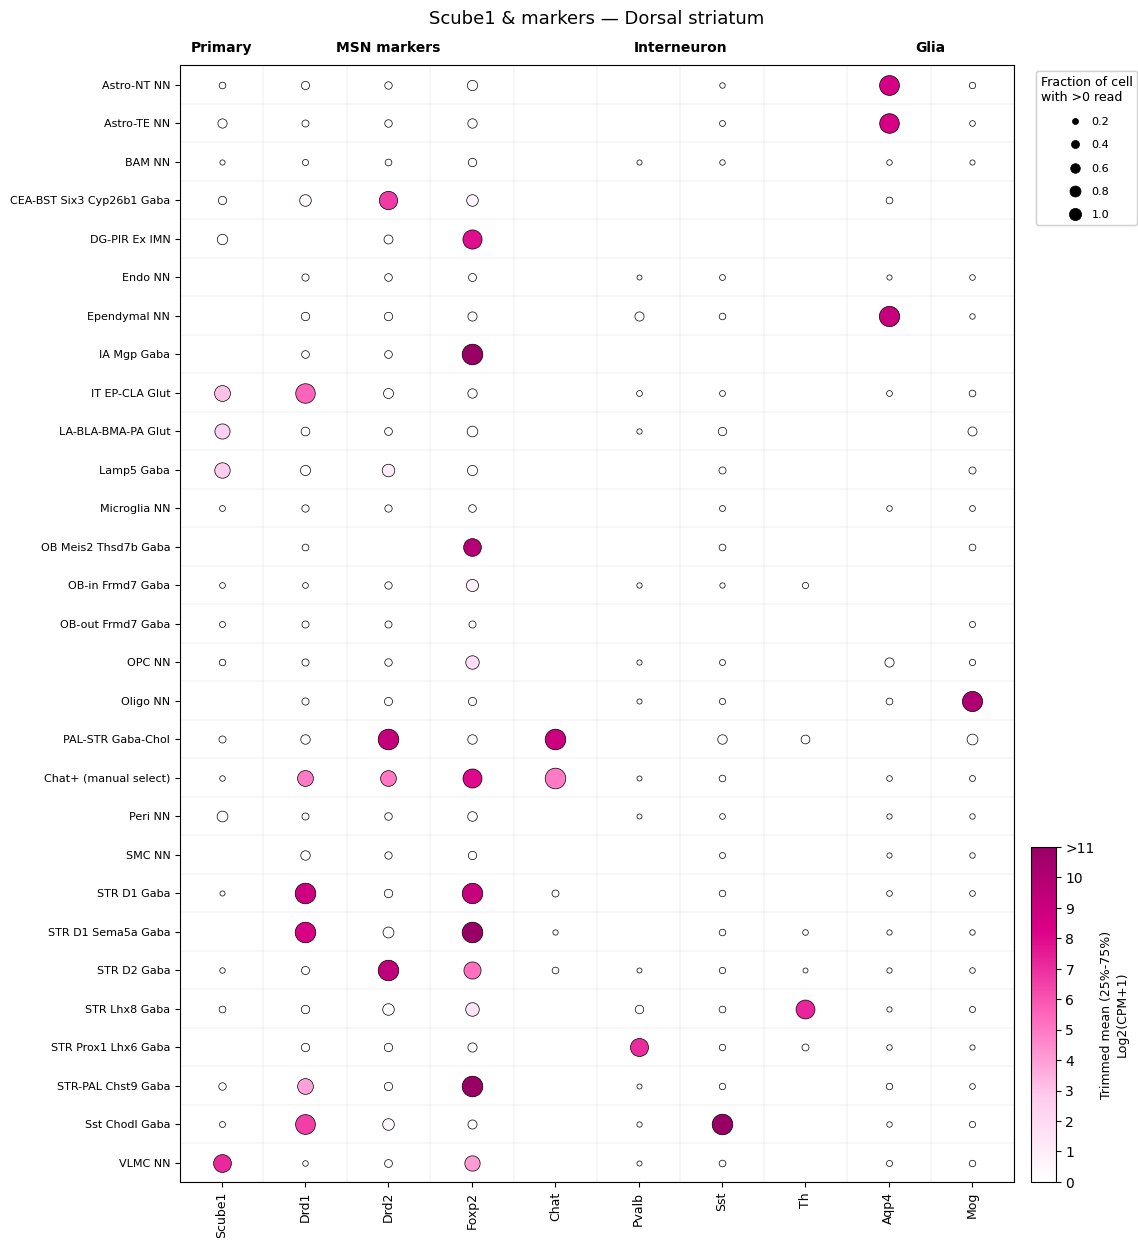

/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")



Ventral striatum: 52,624 cells, 42 groups
  ABC NN: n=10
  ACB-BST-FS D1 Gaba: n=305
  Astro-NT NN: n=168
  Astro-TE NN: n=5,989
  BAM NN: n=157
  CEA-AAA-BST Six3 Sp9 Gaba: n=65
  Endo NN: n=1,566
  GPe-SI Sox6 Cyp26b1 Gaba: n=15
  HPF CR Glut: n=51
  IA Mgp Gaba: n=20
  IT AON-TT-DP Glut: n=164
  LSX Prdm12 Slit2 Gaba: n=39
  Lamp5 Gaba: n=45
  Microglia NN: n=1,686
  NDB-SI-MA-STRv Lhx8 Gaba: n=15
  NDB-SI-ant Prdm12 Gaba: n=96
  OB Dopa-Gaba: n=29
  OB Meis2 Thsd7b Gaba: n=52
  OB Trdn Gaba: n=11
  OB-in Frmd7 Gaba: n=113
  OB-out Frmd7 Gaba: n=42
  OPC NN: n=1,700
  OT D3 Folh1 Gaba: n=7,665
  Oligo NN: n=2,588
  PAL-STR Gaba-Chol: n=77
  Chat+ (manual select): n=372
  Peri NN: n=363
  Pvalb Gaba: n=19
  SI-MA-ACB Ebf1 Bnc2 Gaba: n=44
  SI-MA-LPO-LHA Skor1 Glut: n=105
  SI-MPO-LPO Lhx8 Gaba: n=15
  SMC NN: n=204
  STR D1 Gaba: n=12,350
  STR D1 Sema5a Gaba: n=2,707
  STR D2 Gaba: n=11,148
  STR Lhx8 Gaba: n=326
  STR Prox1 Lhx6 Gaba: n=412
  STR-PAL Chst9 Gaba: n=1,349
  Sst Chod

Saved: scube1/dotplot_STRv_Scube1_by_subclass.png


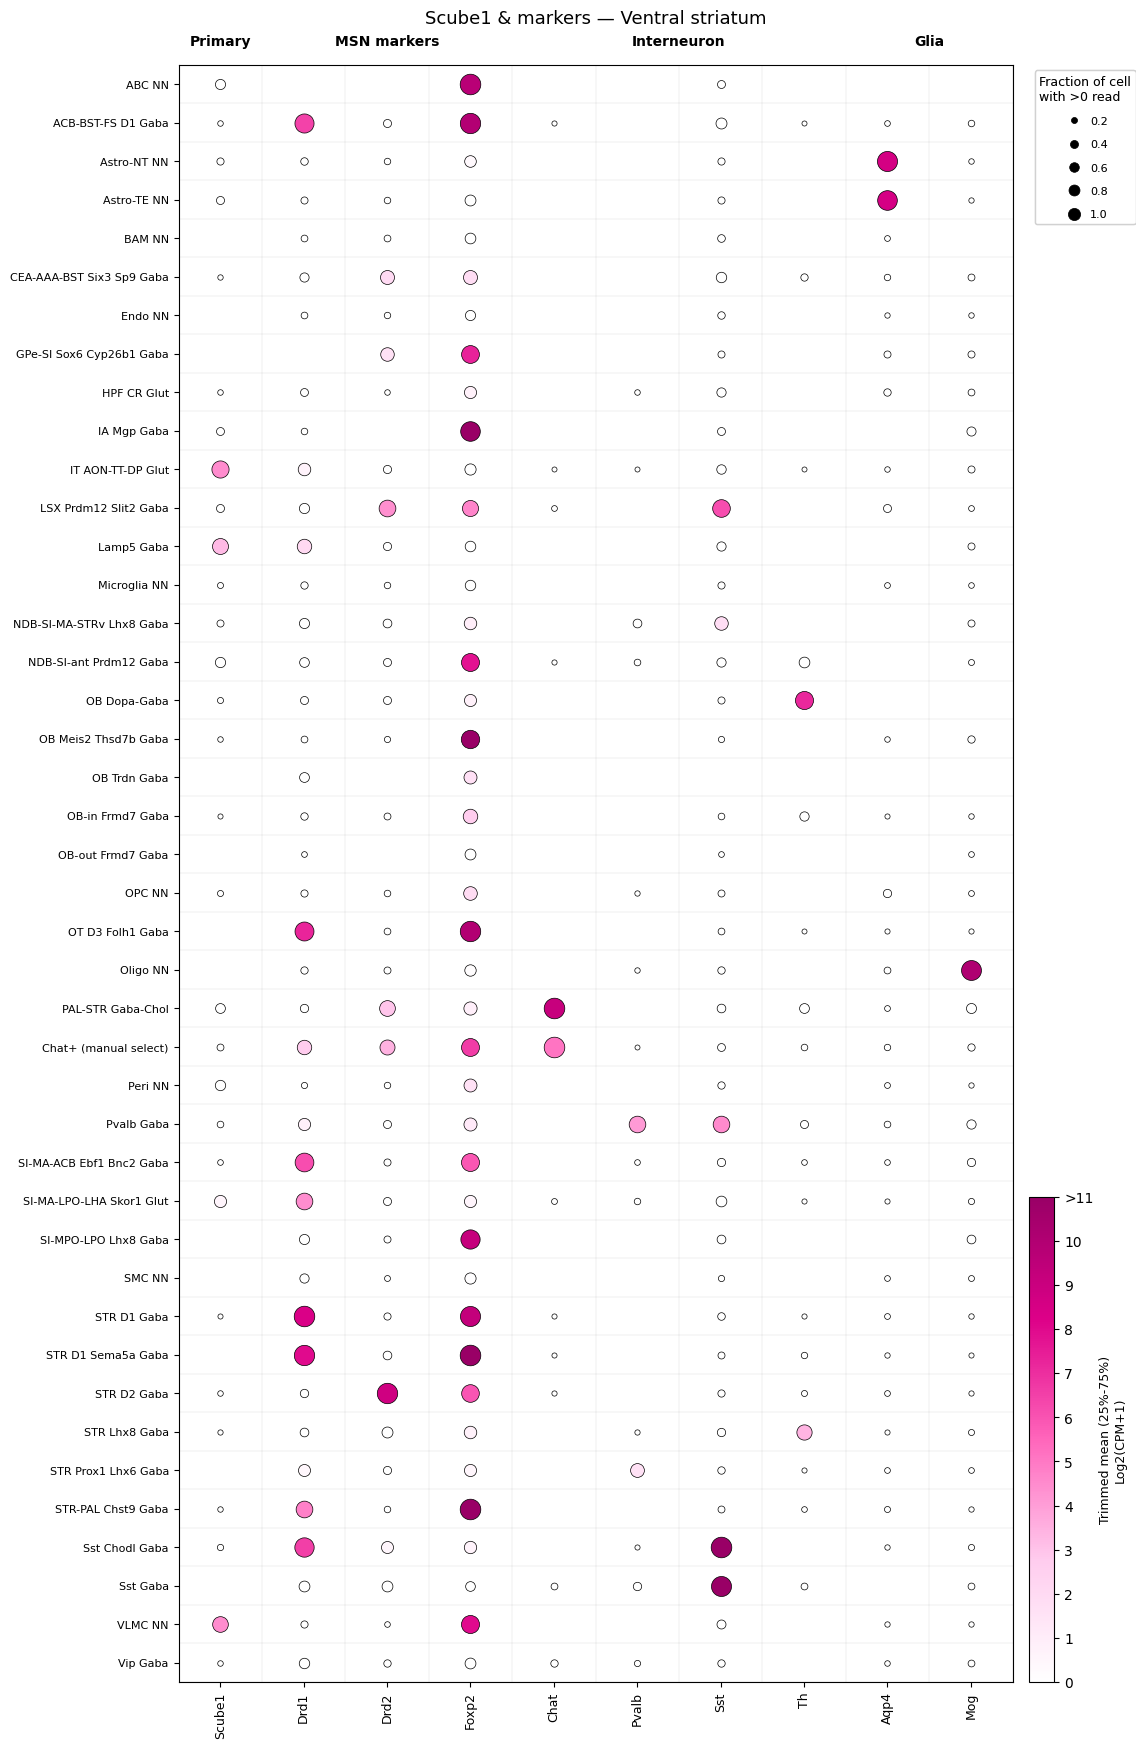

In [15]:
for region in ['STRd', 'STRv']:
    # Subset the adata_with_chat (which includes Chat+ manual group)
    adata_region = adata_with_chat[adata_with_chat.obs['region_of_interest_acronym'] == region].copy()
    region_name = region_map[region]

    # Skip subclasses with very few cells in this region
    min_cells = 10
    sub_counts = adata_region.obs.groupby('subclass_short', observed=True).size()
    valid_subs = sub_counts[sub_counts >= min_cells].index
    adata_region = adata_region[adata_region.obs['subclass_short'].isin(valid_subs)].copy()

    # Preserve ordering from ordered_cats, filtered to valid subs
    region_cats = [c for c in ordered_cats if c in valid_subs]
    adata_region.obs['subclass_short'] = pd.Categorical(
        adata_region.obs['subclass_short'], categories=region_cats, ordered=True
    )
    n_sub = len(region_cats)

    # Print per-group cell counts for this region
    print(f"\n{region_name}: {adata_region.n_obs:,} cells, {n_sub} groups")
    reg_counts = adata_region.obs.groupby('subclass_short', observed=True).size()
    for name in region_cats:
        if name in reg_counts.index:
            print(f"  {name}: n={reg_counts[name]:,}")

    custom_dotplot(
        adata_region,
        gene_groups=gene_groups,
        groupby='subclass_short',
        title=f'Scube1 & markers — {region_name}',
        figsize=(12, max(5, n_sub * 0.5)),
        outpath=outdir / f'dotplot_{region}_Scube1_by_subclass.png',
    )

## 9. Summary Statistics

In [16]:
# Mean expression and fraction expressing per subclass
expr_df = pd.DataFrame(
    adata.X,
    index=adata.obs.index,
    columns=adata.var.index
)
expr_df['subclass'] = adata.obs['subclass_short'].values
expr_df['region'] = adata.obs['region_of_interest_acronym'].values

print("=== Mean Scube1 expression by subclass and region ===")
summary = expr_df.groupby(['subclass', 'region']).agg(
    n_cells=('Scube1', 'size'),
    mean_expr=('Scube1', 'mean'),
    frac_expressing=('Scube1', lambda x: (x > 0).mean())
).round(4)
print(summary.to_string())

=== Mean Scube1 expression by subclass and region ===
                                     n_cells  mean_expr  frac_expressing
subclass                     region                                     
ABC NN                       STRd          0        NaN              NaN
                             STRv         10     1.2556           0.2000
ACB-BST-FS D1 Gaba           STRd          2     0.0000           0.0000
                             STRv        305     0.0872           0.0197
AVPV-MEPO-SFO Tbr1 Glut      STRd          0        NaN              NaN
                             STRv          3     1.5527           0.3333
Astro-NT NN                  STRd        111     0.3896           0.0541
                             STRv        168     0.4984           0.0714
Astro-OLF NN                 STRd          0        NaN              NaN
                             STRv          2     0.0000           0.0000
Astro-TE NN                  STRd       6190     1.0811           0.15

/tmp/ipykernel_2473/2090688530.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = expr_df.groupby(['subclass', 'region']).agg(
